In [2]:
from networks.dcase2023t2_ae.network import AENet
import torch.nn.functional as F
from datasets.datasets import Datasets
from tqdm import tqdm
import common as com
import torch
import numpy as np
import pandas as pd

param = com.yaml_load()
parser = com.get_argparse()
# read parameters from yaml
flat_param = com.param_to_args_list(params=param)
args = parser.parse_args(args=flat_param)
# set command line arguments
args.dataset = 'DCASE2024T2CoffeeGrinder'
args.dev = True
args.eval = False
args.train = False
args.test = True
args.test_only = True
# read parameters from command line
print(args)

dataset = Datasets('DCASE2024T2CoffeeGrinder').data(args)
test_loader = dataset.test_loader[0]

block_size = dataset.height
model = AENet(input_dim=dataset.input_dim, block_size=block_size)

# load the model parameters from the checkpoint
checkpoint_path = './models/saved_model/baseline/DCASE2023T2-AE_DCASE2024T2CoffeeGrinder_seed13711.pth'
checkpoint = torch.load(checkpoint_path, map_location='cpu')
model.load_state_dict(checkpoint)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

embd_list = []
metadata= []

for batch_idx, batch in enumerate(tqdm(test_loader)):
    data = batch[0]
    data = data.to(device).float()
    if data.shape[0] <= 1:
        continue

    data_name_list = batch[3]
    recon_batch, z = model(data)
    labels = []

    for name in data_name_list:
        parts = name.split('_')
        labels.append({
            'condition': parts[4] if len(parts) > 4 else 'UNK',
            'domain': parts[2] if len(parts) > 2 else 'UNK',
            'position': parts[10] if len(parts) > 9 else 'UNK',
            'grind size': parts[-1].split('.')[0] if len(parts) > 0 else 'UNK',
            'mic': parts[7] if len(parts) > 7 else 'UNK'
        })

    metadata.extend(labels)
    embd_list.append(z.cpu().detach().numpy())

embd_all = np.vstack(embd_list)

Namespace(model='DCASE2023T2-AE', score='MSE', seed=13711, use_cuda=True, gpu_id=[0], log_interval=100, decision_threshold=0.9, max_fpr=0.1, n_mels=128, frames=5, frame_hop_length=1, n_fft=1024, hop_length=512, power=2.0, fmin=0.0, fmax=None, win_length=None, batch_size=256, epochs=100, learning_rate=0.001, shuffle='True', validation_split=0.1, dataset_directory='./data', dataset='DCASE2024T2CoffeeGrinder', dev=True, eval=False, use_ids=[], is_auto_download=False, result_directory='./results', export_dir='baseline', model_name_suffix='', restart=False, checkpoint_path='', train_only=False, test_only=True, train=False, test=True)
input dim: 640
num classes: 1
dataset dir is exists.
============== DATASET_GENERATOR ==============
Setup has already been completed.
c:\Projects_code\ANOMALOUS_SOUND_DETECTION\dcase2023_task2_baseline_ae_official\data\dcase2024t2\dev_data\processed\CoffeeGrinder\train\mels128_fft1024_hop512\section_00_mix_TF5-1_mel1024-512.pickle is exists.
load pickle : c:\P

100%|██████████| 196/196 [00:00<00:00, 238.19it/s]


In [25]:
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("t-SNE fitting in progress... 🔄")

PERPLEXITY = 100
N_COMPONENTS = 2
tsne = TSNE(n_components=N_COMPONENTS, perplexity=PERPLEXITY, n_iter=1000, random_state=42)
embd_tsne = tsne.fit_transform(embd_all)

t-SNE fitting in progress... 🔄


c:\Projects_code\ANOMALOUS_SOUND_DETECTION\dcase2023_task2_baseline_ae_official\.venv\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [26]:
# Create a DataFrame for the t-SNE results
df_tsne = pd.DataFrame(embd_tsne, columns=['x', 'y'])
df_tsne['condition'] = [label['condition'] for label in metadata]
df_tsne['domain'] = [label['domain'] for label in metadata]
df_tsne['position'] = [label['position'] for label in metadata]
df_tsne['grind size'] = [label['grind size'] for label in metadata]
df_tsne['mic'] = [label['mic'] for label in metadata]

df_tsne


,x,y,condition,domain,position,grind size,mic
0,9.510760,49.118252,normal,source,A,0,imp23absu
1,9.696609,49.573196,normal,source,A,0,imp23absu
2,9.852912,49.802528,normal,source,A,0,imp23absu
3,9.698002,50.135006,normal,source,A,0,imp23absu
4,8.892578,49.986450,normal,source,A,0,imp23absu
...,...,...,...,...,...,...,...
29983,-19.783377,25.113905,anomaly,target,C,300,imp34dt05
29984,-21.178207,23.498314,anomaly,target,C,300,imp34dt05
29985,-22.055437,24.583614,anomaly,target,C,300,imp34dt05
29986,-21.157270,25.251278,anomaly,target,C,300,imp34dt05


In [27]:
perplexity = 100
from pathlib import Path
# Create directory for saving t-SNE results
tsne_dir = Path('visualizations/tsne')
tsne_dir.mkdir(parents=True, exist_ok=True)
# Save the t-SNE results to a CSV file
df_tsne.to_csv( tsne_dir / f'tsne_embeddings_perpl{PERPLEXITY}_ncomp{N_COMPONENTS}.csv')

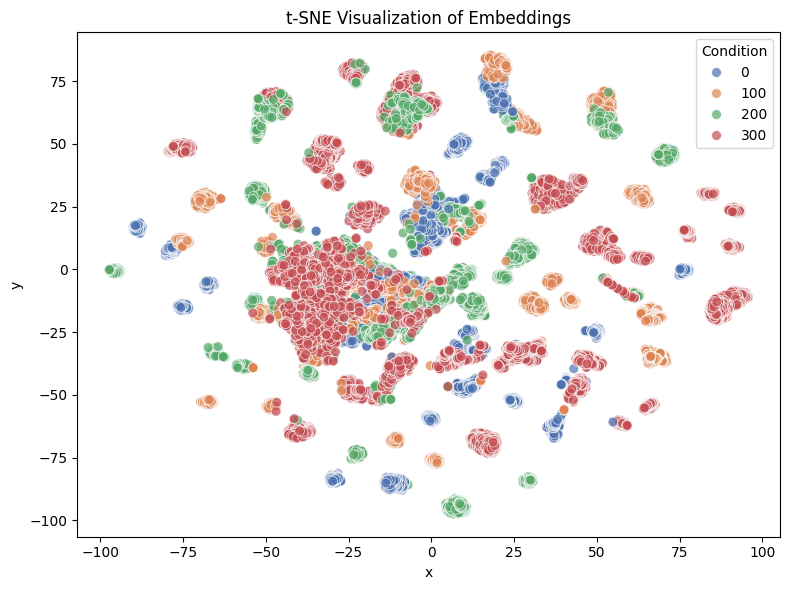

In [28]:
# plot per confrontare le grind size
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='x',
    y='y',
    hue='grind size',
    data=df_tsne,
    palette="deep",
    alpha=0.7,
    s=50,
)

plt.title(f't-SNE Visualization of Embeddings')
plt.legend(title='Condition')
plt.tight_layout()
plt.savefig(tsne_dir / f'tsne_embeddings_perpl{PERPLEXITY}_ncomp{N_COMPONENTS}.svg', format='svg', dpi=600)
plt.show()

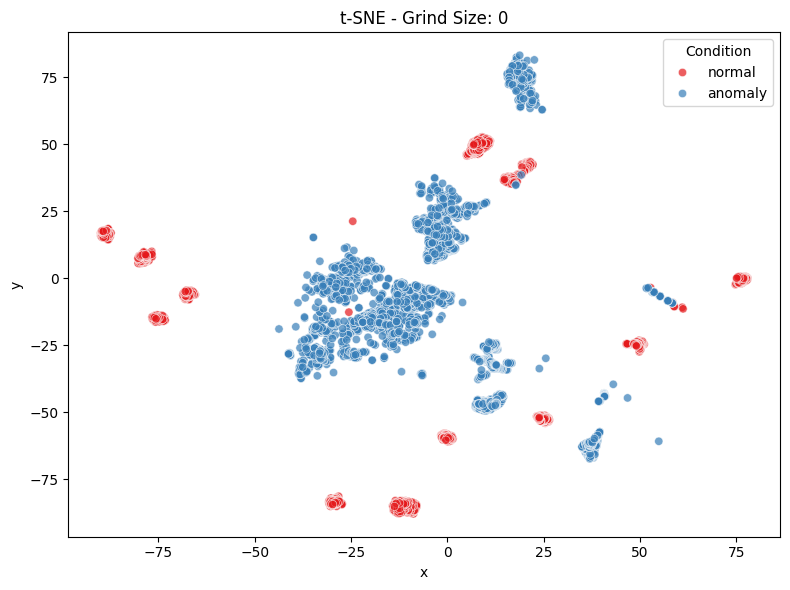

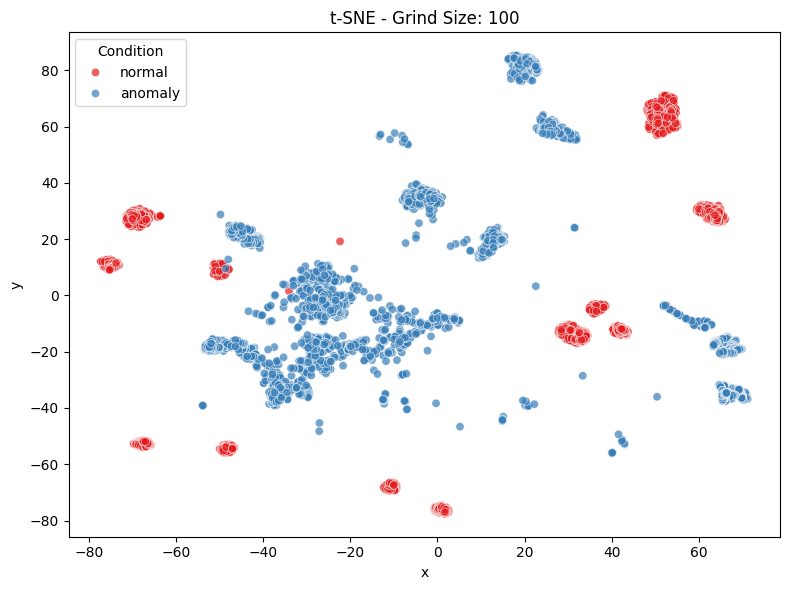

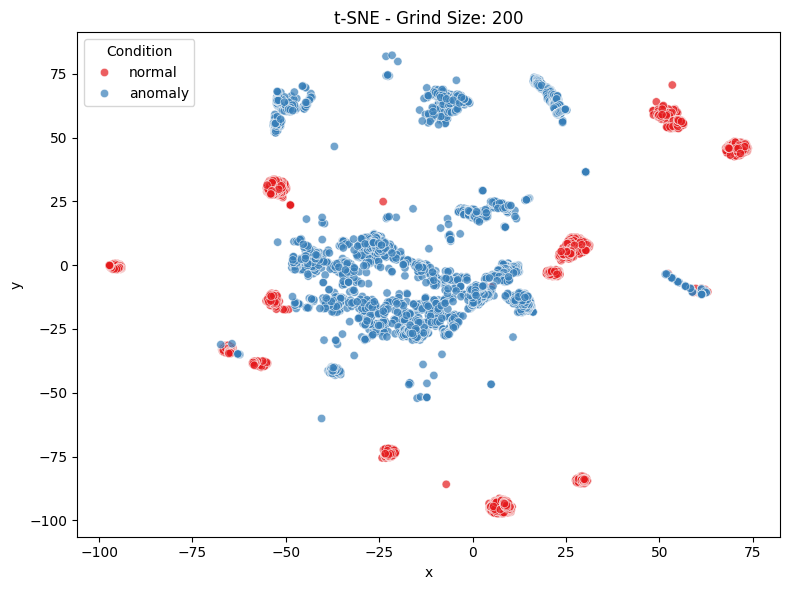

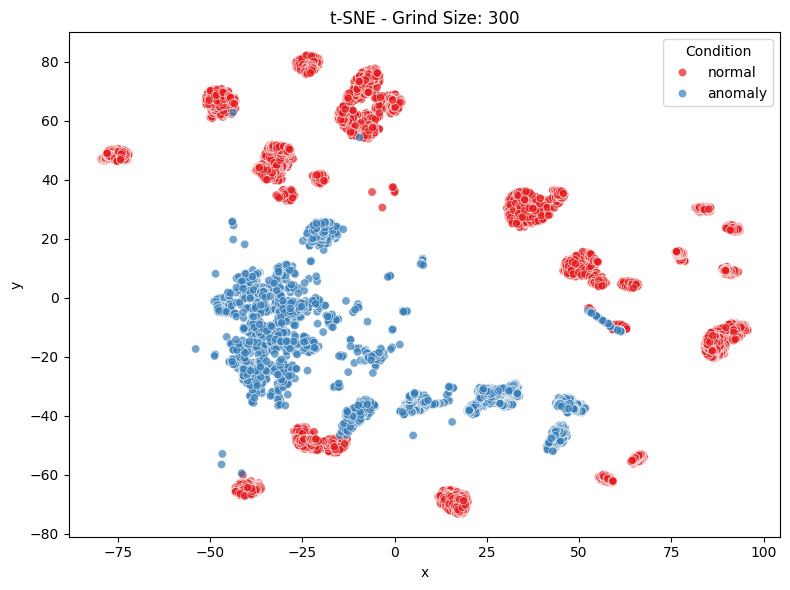

In [29]:
# Plot per ogni grind size
unique_grinds = df_tsne['grind size'].unique()

for grind in unique_grinds:
    subset = df_tsne[df_tsne['grind size'] == grind]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x='x', y='y',
        hue='condition',  # oppure 'Type' se lo hai messo
        data=subset,
        palette='Set1',
        alpha=0.7
    )
    plt.title(f't-SNE - Grind Size: {grind}')
    plt.legend(title='Condition')
    plt.tight_layout()
    plt.savefig(tsne_dir / f'tsne_grind{grind}_perp{perplexity}.svg', format='svg', dpi=600)
    plt.show()

In [ ]:
import umap

print("UMAP fitting in progress... 🌌")

NEIGHBORS = 1000
MIN_DIST = 0.1
N_COMPONENTS = 2

umap_reducer = umap.UMAP(n_neighbors=NEIGHBORS, min_dist=MIN_DIST, n_components=N_COMPONENTS, random_state=42)
embd_umap = umap_reducer.fit_transform(embd_all)

UMAP fitting in progress... 🌌


c:\Projects_code\ANOMALOUS_SOUND_DETECTION\dcase2023_task2_baseline_ae_official\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Projects_code\ANOMALOUS_SOUND_DETECTION\dcase2023_task2_baseline_ae_official\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [12]:
# Create a DataFrame for UMAP results
df_umap = pd.DataFrame(embd_umap, columns=['x', 'y'])
df_umap['condition'] = [label['condition'] for label in metadata]
df_umap['domain'] = [label['domain'] for label in metadata]
df_umap['position'] = [label['position'] for label in metadata]
df_umap['grind size'] = [label['grind size'] for label in metadata]
df_umap['mic'] = [label['mic'] for label in metadata]

In [ ]:
from pathlib import Path

# save the UMAP results to a CSV file
umap_dir = Path('visualizations/umap')
umap_dir.mkdir(parents=True, exist_ok=True)
# Save the UMAP results to a CSV file
df_umap.to_csv(umap_dir / f'umap_embeddings_neighbors{NEIGHBORS}.csv')

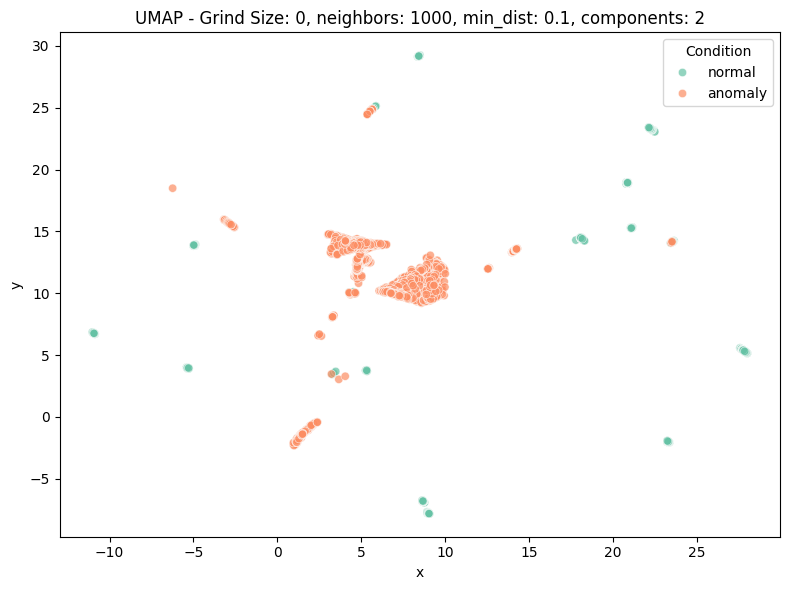

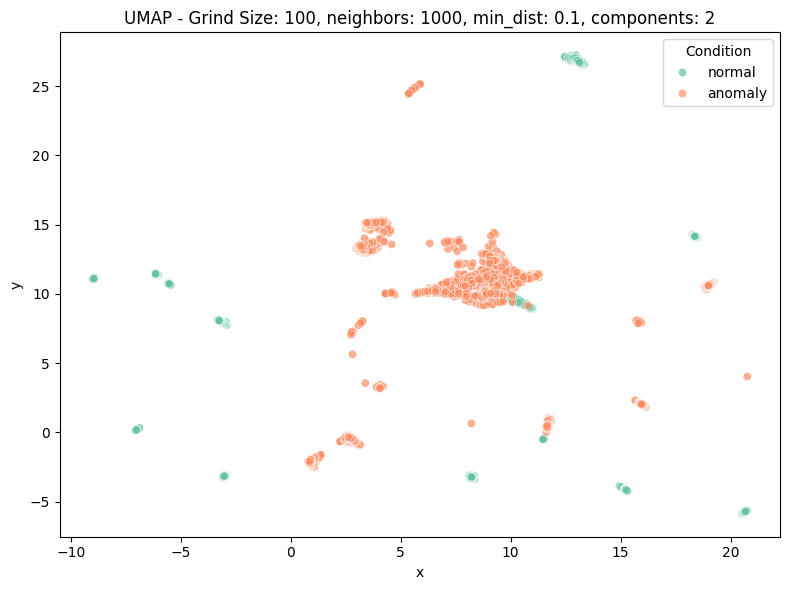

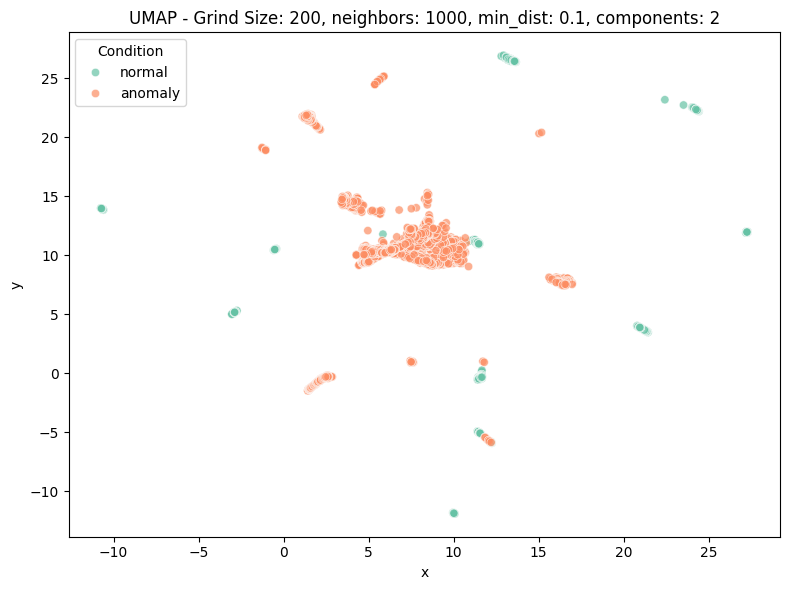

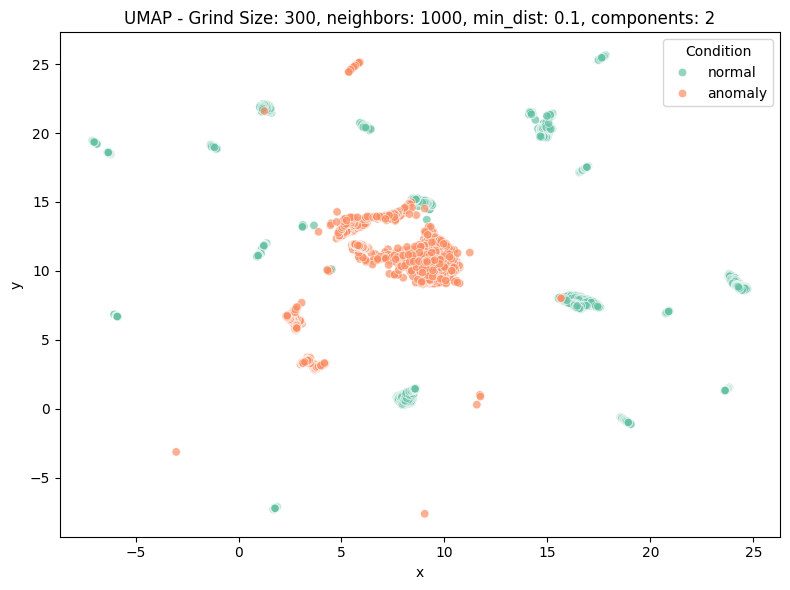

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_grinds = df_umap['grind size'].unique()

for grind in unique_grinds:
    subset = df_umap[df_umap['grind size'] == grind]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x='x', y='y',
        hue='condition',
        data=subset,
        palette='Set2',
        alpha=0.7
    )
    plt.title(f'UMAP - Grind Size: {grind}, neighbors: {NEIGHBORS}, min_dist: {MIN_DIST}, components: {N_COMPONENTS}')
    plt.legend(title='Condition')
    plt.tight_layout()
    plt.savefig(umap_dir / f'umap_grind{grind}_neighbors{NEIGHBORS}.svg', dpi=600)
    plt.show()


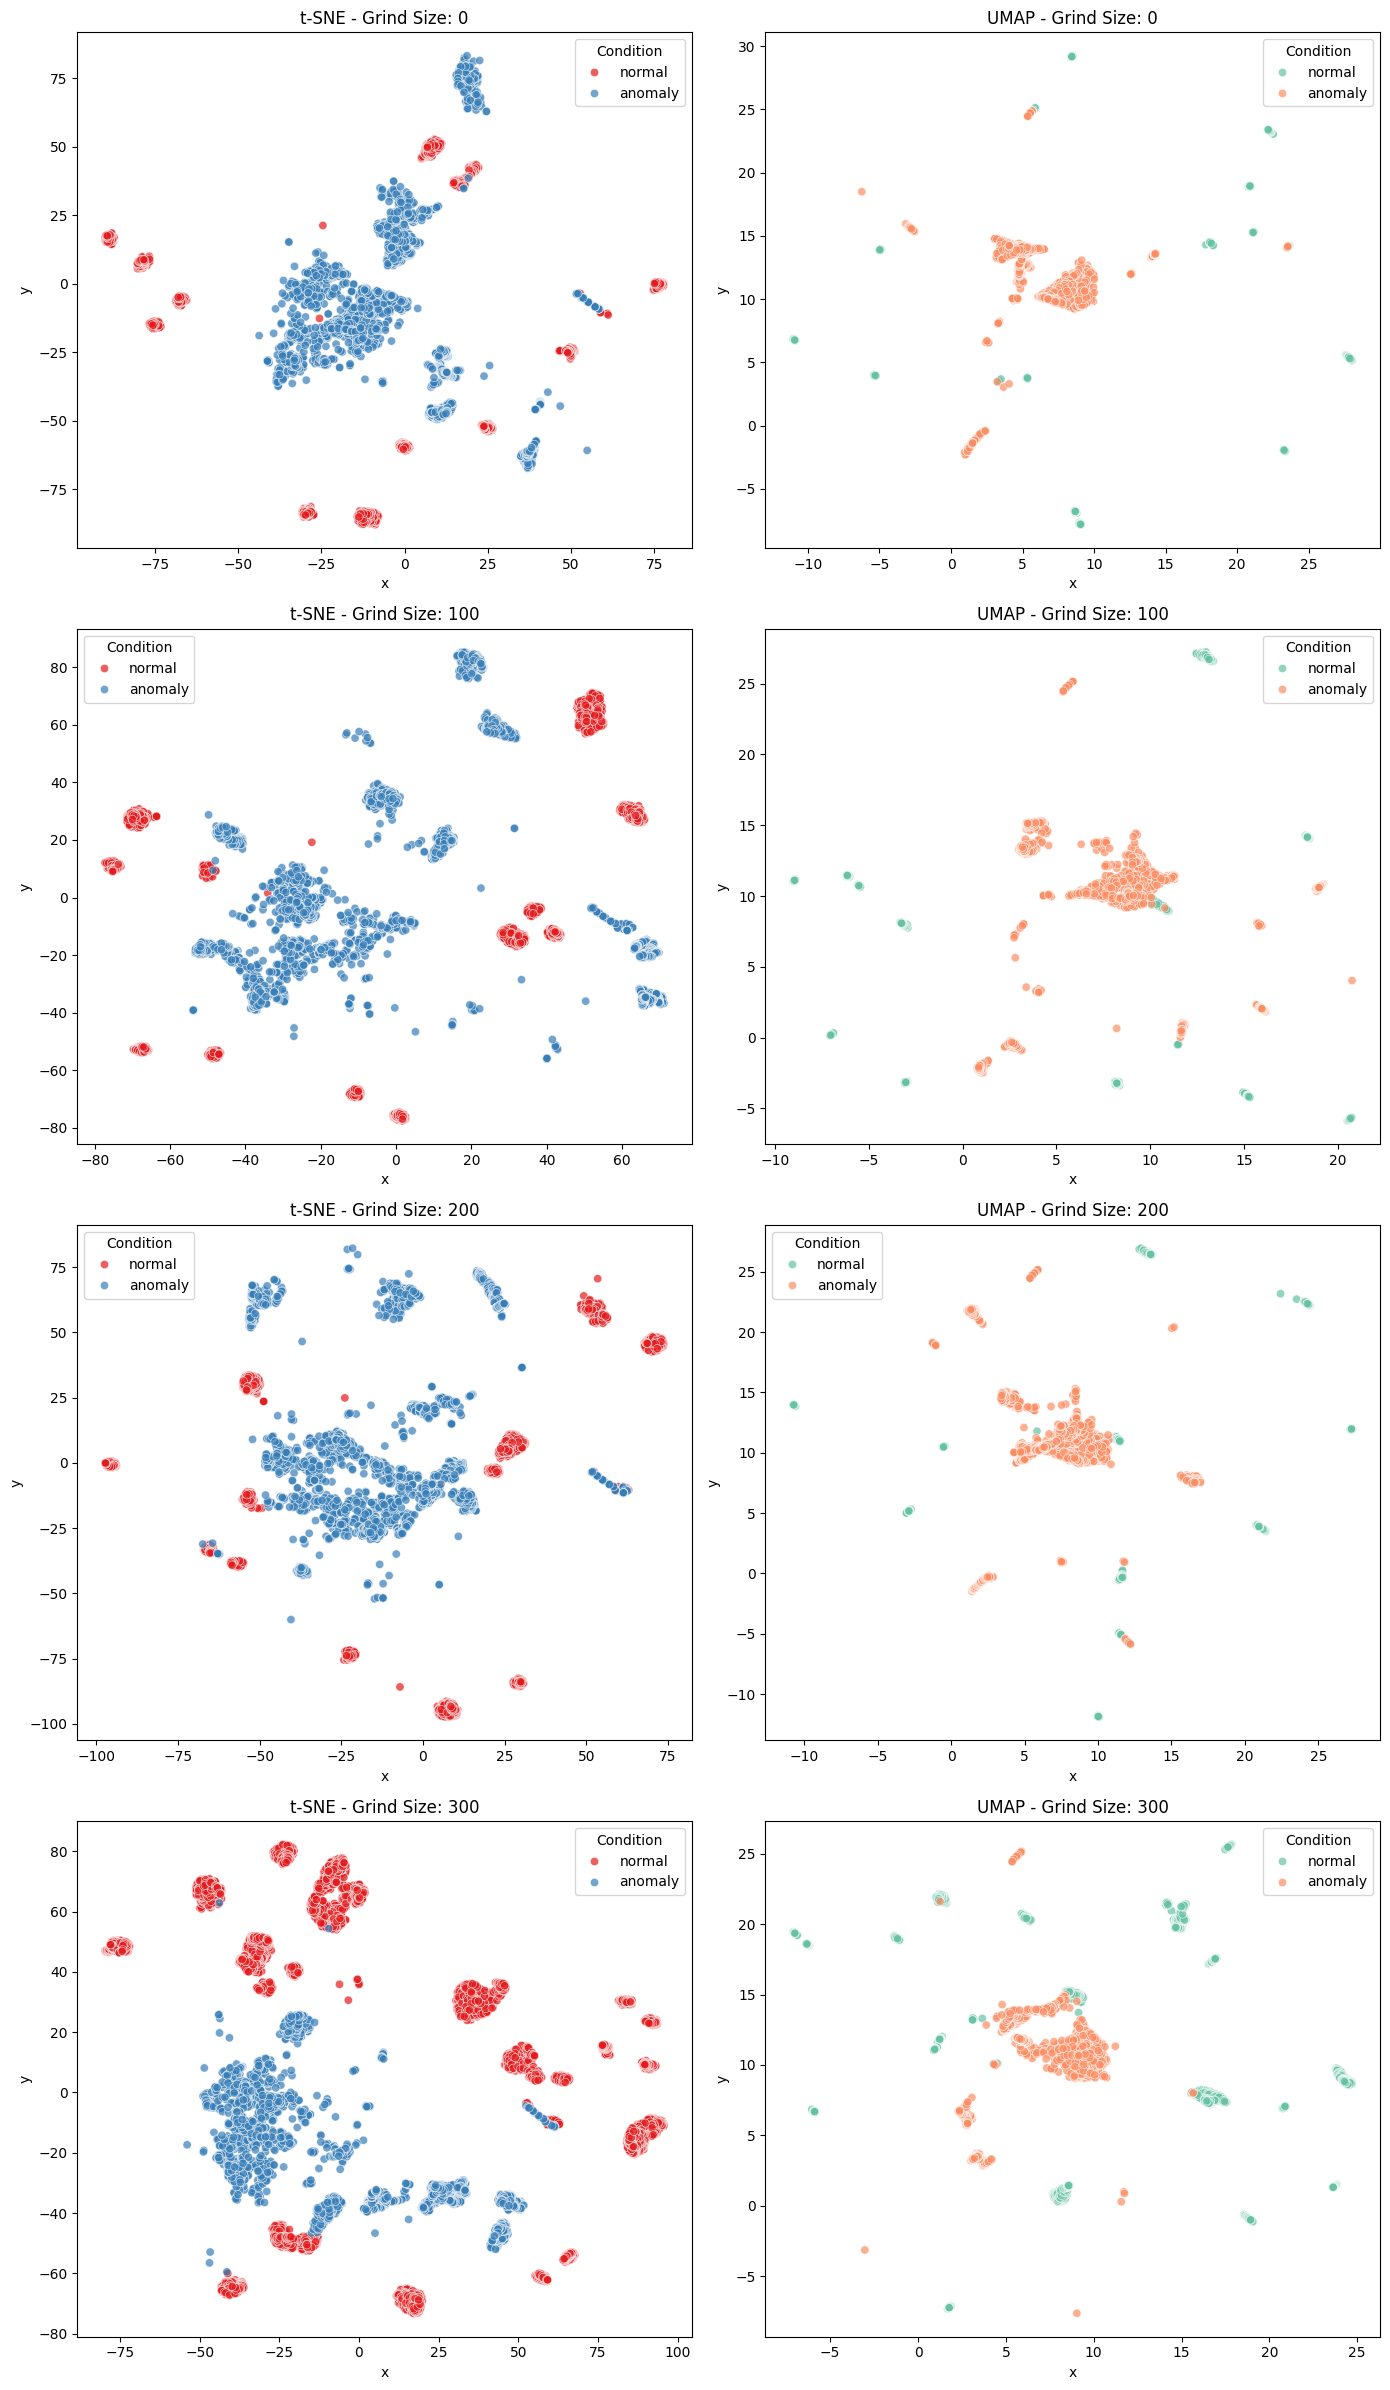

In [31]:
fig, axes = plt.subplots(len(unique_grinds), 2, figsize=(14, 6 * len(unique_grinds)))

for idx, grind in enumerate(unique_grinds):
    tsne_subset = df_tsne[df_tsne['grind size'] == grind]
    umap_subset = df_umap[df_umap['grind size'] == grind]

    sns.scatterplot(ax=axes[idx, 0], x='x', y='y', hue='condition', data=tsne_subset, palette='Set1', alpha=0.7)
    axes[idx, 0].set_title(f't-SNE - Grind Size: {grind}')
    axes[idx, 0].legend(title='Condition')

    sns.scatterplot(ax=axes[idx, 1], x='x', y='y', hue='condition', data=umap_subset, palette='Set2', alpha=0.7)
    axes[idx, 1].set_title(f'UMAP - Grind Size: {grind}')
    axes[idx, 1].legend(title='Condition')

plt.tight_layout()
plt.savefig(Path('visualizations') / f'combined_tsne_umap.svg', dpi=600)
plt.show()